# L13 worked example: a fed-batch bioreactor as a neural ODE and as a neural DAE

This notebook is the code of the lecture, in the order of the lecture. Every code cell from the
slides is here, unchanged; the cells in between make the data, print and plot.

1. **The data**: three batches of a fed-batch bioreactor, as in the SiNDAE fed-batch example.
2. **A neural ODE**, trained the sequential way with **Diffrax** (differentiable ODE solvers in
   JAX, https://docs.kidger.site/diffrax/) and **Equinox** (neural networks in JAX,
   https://docs.kidger.site/equinox/).
3. **A neural DAE**, trained the simultaneous way with **SiNDAE**
   (https://github.com/Alves-research-group/SiNDAE). This part follows the SiNDAE example
   [Importing Measured Data, Fed-Batch Bioreactor](https://alves-research-group.github.io/SiNDAE/fedbatch-example/)
   step for step, with the product balance diluted by $F/V$, as in Eq. (30b) of Lueg et al.
   (2026). SiNDAE writes the model in **Pyomo** (https://www.pyomo.org), discretizes it with
   **Pyomo.DAE**, and solves one nonlinear program with the **POUNCE** interior-point solver.
4. **A new batch**, predicted by both.

`pip install sindae diffrax` installs everything; no licensed solver is needed.

The bioreactor has four states: biomass $X$, product $P$, substrate $S$ and volume $V$:

$$
\begin{align}
\frac{dX}{dt} &= \mu X - \frac{F}{V}X \tag{1}\\
\frac{dP}{dt} &= Y_{px}\,\mu X - \frac{F}{V}P \tag{2}\\
\frac{dS}{dt} &= \frac{F}{V}(S_f - S) - \frac{\mu X}{Y_{xs}} \tag{3}\\
\frac{dV}{dt} &= F \tag{4}
\end{align}
$$

The unknown term is the specific growth rate $\mu$, learned by a network of the four states.
The true kinetics are the Monod law, $\mu = \mu_{max}\, S / (K_s + S)$; we use it only to
make the measurements and to check the result.

> Companion notes: [`notes.md`](notes.md).

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [ ]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "diffrax": "diffrax",
    "equinox": "equinox",
    "jax": "jax",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "optax": "optax",
    "pandas": "pandas",
    "pyomo": "pyomo",
    "scipy": "scipy",
    "sindae": "sindae",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


In [2]:
%matplotlib inline

import logging

import diffrax
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import pyomo.dae as dae
import pyomo.environ as pyo
from scipy.integrate import solve_ivp

from sindae import HybridDAE
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.algorithms.smoother import SmootherConfig
from sindae.nn_utils import SimpleMLP
from sindae.plot_utils import plot_instance_data
from sindae.problem import ProblemDefinition
from sindae.solvers import SolverConfig

jax.config.update("jax_enable_x64", True)
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
)
logging.getLogger("pyomo").setLevel(logging.ERROR)
logging.getLogger("cyipopt").setLevel(logging.WARNING)

## Step 1: the measured data

The parameters: yields and feed rate, and the true Monod constants, which only the measurements
and the final check use.

In [3]:
FB_PARAMS = {
    "Feed": 0.05,     # F: volumetric feed rate (L/h)
    "Ypx": 0.2,       # product yield
    "Yxs": 0.5,       # biomass yield on substrate
    "Ks": 1.0,        # Monod half-saturation (measurements and final check only)
    "mu_max": 0.2,    # Monod maximum growth rate (measurements and final check only)
}
F, Ypx, Yxs = FB_PARAMS["Feed"], FB_PARAMS["Ypx"], FB_PARAMS["Yxs"]
STATE_NAMES = ["$X$ (biomass)", "$P$ (product)", "$S$ (substrate)", "$V$ (volume)"]
OUTPUT_NAME = [r"$\mu$ (growth rate)"]
SEED = 0

The SiNDAE example reads `fedbatch_measurements.csv`, made by its script
`generate_fedbatch_data.py` from the true model. We make the same table here: three batches,
40 h, every fourth point of a 40-element, 3-point Radau grid (31 samples per batch), and noise
of standard deviation 0.05, 0.05, 0.5 and 0.1 on $X$, $P$, $S$ and $V$.

In [4]:
BATCH_ICS = np.array([
    [0.05, 0.0, 10.0, 1.00],    # batch 0
    [0.025, 0.0, 5.0, 0.80],    # batch 1
    [0.5, 0.0, 7.5, 0.95],      # batch 2
])
MEASUREMENT_NOISE = np.array([0.05, 0.05, 0.5, 0.1])    # standard deviation per state


def true_rhs(t, x, Sf):
    X, P, S, V = x
    mu = FB_PARAMS["mu_max"] * S / (FB_PARAMS["Ks"] + S)
    return [mu * X - F / V * X,
            Ypx * mu * X - F / V * P,
            F / V * (Sf - S) - mu * X / Yxs,
            F]


radau = (0.155051, 0.644949, 1.0)
grid = np.array([0.0] + [i + c for i in range(40) for c in radau])
sample_times = grid[::4]
rng = np.random.default_rng(SEED)
records = []
for batch_id, ic in enumerate(BATCH_ICS):
    sol = solve_ivp(
        true_rhs,
        (0, 40),
        ic,
        t_eval=sample_times,
        args=(ic[2],),
        rtol=1e-10,
        atol=1e-12,
    )
    noisy = sol.y.T + rng.normal(0, 1, sol.y.T.shape) * MEASUREMENT_NOISE
    for k, t in enumerate(sample_times):
        records.append({"batch": batch_id, "time": t, "X": noisy[k, 0], "P": noisy[k, 1],
                        "S": noisy[k, 2], "V": noisy[k, 3]})
raw = pd.DataFrame(records)
raw.head()

,batch,time,X,P,S,V
0,0,0.000000,0.056287,-0.006605,10.320211,1.010490
1,0,1.155051,0.031532,0.020289,10.629909,1.152461
2,0,2.644949,0.036235,-0.057819,9.633839,1.136380
3,0,4.000000,-0.030049,-0.002032,9.287973,1.126773
4,0,5.155051,0.074230,-0.003477,10.082436,1.362004


Group the table by batch, as the SiNDAE example does: `obs_times` and `obs_values` hold one
array per batch.

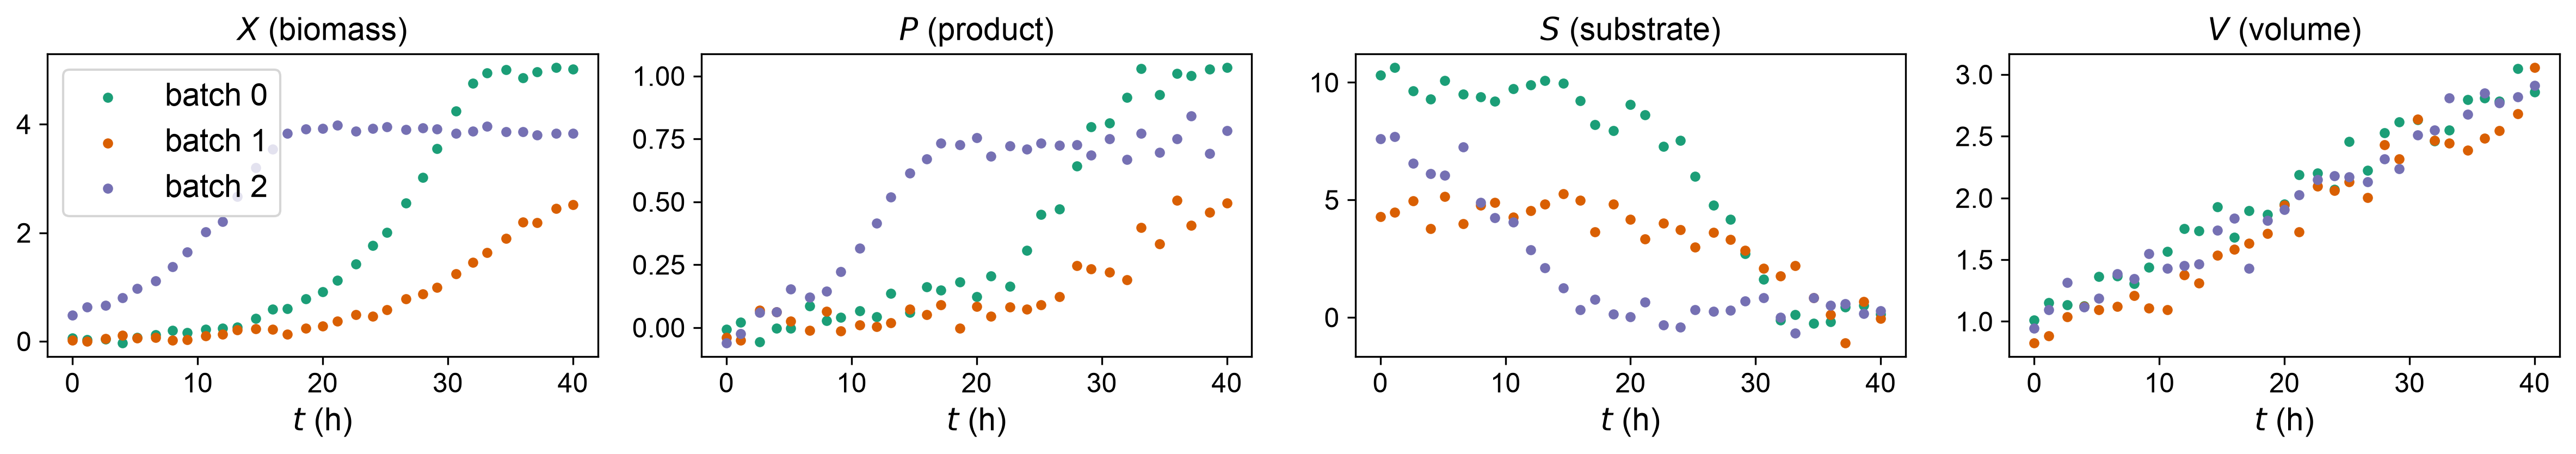

In [5]:
MEASURED_COLS = ["X", "P", "S", "V"]

obs_times = []
obs_values = []
for batch_id in sorted(raw["batch"].unique()):
    batch = raw[raw["batch"] == batch_id].sort_values("time")
    obs_times.append(batch["time"].to_numpy())
    obs_values.append(batch[MEASURED_COLS].to_numpy())

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for j, name in enumerate(STATE_NAMES):
    for b_ in range(len(obs_times)):
        axes[j].scatter(
            obs_times[b_],
            obs_values[b_][:, j],
            s=12,
            label=f"batch {b_}",
        )
    axes[j].set_title(name)
    axes[j].set_xlabel("$t$ (h)")
axes[0].legend()
plt.tight_layout()
plt.show()

## Step 2: a neural ODE, trained sequentially

The balances are known; a small Equinox network gives $\mu$ from the four states.

- `x_typical` divides each state by a typical value, so the network sees numbers near 1.
- softplus is always positive, so $\mu \ge 0$; at the start it is about 0.7, so `mu_scale`
  makes $\mu$ start near 0.2 1/h. **Nothing keeps $S \ge 0$.**

In [6]:
mu_scale = 0.3                                 # 1/h: sets the size of mu
x_typical = jnp.array([5.0, 1.0, 10.0, 3.0])   # typical X, P, S, V

class GrowthRate(eqx.Module):
    mlp: eqx.nn.MLP

    def __call__(self, x):
        out = self.mlp(x / x_typical)[0]       # any real number
        return mu_scale * jax.nn.softplus(out) # mu >= 0, of order mu_scale

The balances, one line per equation: the right-hand side of the ODE, in the form Diffrax wants.

In [7]:
def balances(t, x, args):
    mu_net, Sf = args
    X, P, S, V = x
    mu = mu_net(x)                               # the learned term
    dX = mu * X - F / V * X
    dP = Ypx * mu * X - F / V * P
    dS = F / V * (Sf - S) - mu * X / Yxs
    dV = F
    return jnp.array([dX, dP, dS, dV])

`diffrax.diffeqsolve` integrates it: `Tsit5` is Tsitouras' fifth-order Runge-Kutta method,
`SaveAt` returns the states at the sample times, and `PIDController` adapts the step to the
tolerances. Every operation is JAX, so `jax.grad` goes back through the solver.

In [8]:
def simulate(mu_net, x0, ts):
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(balances),
        diffrax.Tsit5(),
        t0=0.0,
        t1=ts[-1],
        dt0=0.1,
        y0=x0,
        args=(mu_net, x0[2]),
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(
            rtol=1e-6,
            atol=1e-8,
        ),
    )
    return sol.ys

The measurements as JAX arrays, and the number of training steps.

In [9]:
x0s = jnp.array(BATCH_ICS)
ts = jnp.array(obs_times[0])
ys = jnp.array(obs_values)
y_scale = ys.reshape(-1, 4).std(axis=0)
steps = 10_000

Training is **sequential**: every step simulates the three batches, compares them with the
data (each state divided by its spread), and updates the weights with Adam.
`eqx.filter_value_and_grad` and `eqx.filter_jit` are JAX's `value_and_grad` and `jit` for an
Equinox model. 10,000 steps take about 30 s.

In [10]:
def loss(mu_net):
    pred = jax.vmap(simulate, in_axes=(None, 0, None))(mu_net, x0s, ts)
    return jnp.mean(((pred - ys) / y_scale) ** 2)

mu_net = GrowthRate(eqx.nn.MLP(
    in_size=4,
    out_size=1,
    width_size=16,
    depth=2,
    activation=jnp.tanh,
    key=jax.random.PRNGKey(0),
))
opt = optax.adam(optax.cosine_decay_schedule(1e-2, steps, alpha=0.05))
state = opt.init(eqx.filter(mu_net, eqx.is_array))

@eqx.filter_jit
def step(mu_net, state):
    value, grads = eqx.filter_value_and_grad(loss)(mu_net)
    updates, state = opt.update(grads, state, mu_net)
    return eqx.apply_updates(mu_net, updates), state, value

for _ in range(10_000):
    mu_net, state, value = step(mu_net, state)

In [11]:
print(f"final loss {float(value):.4f}")

final loss 0.0194


## Step 3: a neural DAE, trained simultaneously

The SiNDAE problem: a `ProblemDefinition` subclass. `build_trajectory()` writes the model for
one batch, `get_input_vars()` names the network's inputs (the states) and `get_output_vars()` its
output ($\mu$). There is no formula for $\mu$, and the states are declared non-negative: this
is where $S \ge 0$ is enforced.

In [12]:
class FedBatchBioreactorProblem(ProblemDefinition):
    def __init__(
        self,
        params,
        ics,
        input_dim,
        z_dim,
        t_span,
        nfe,
        ncp,
        obs_times=None,
        obs_values=None,
        obs_dim=None,
    ):
        super().__init__(ics, input_dim, z_dim, t_span, nfe, ncp,
                         obs_times, obs_values, obs_dim)
        self.params = params

    def build_trajectory(self, block, traj_idx):
        p = self.params
        t0 = self.t_span[0]
        x0 = self.ics[traj_idx]
        Sf = float(x0[2])                # feed concentration = initial substrate
        Feed, Ypx, Yxs = p["Feed"], p["Ypx"], p["Yxs"]

        block.t = dae.ContinuousSet(bounds=self.t_span)
        block.x = pyo.Var(
            block.t,
            range(self.input_dim),
            domain=pyo.NonNegativeReals,
            initialize=1.0,
        )
        block.z = pyo.Var(block.t, range(self.z_dim), initialize=0.1)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            mu = b.z[t, 0]               # growth rate, learned by the network
            X, P, S, V = b.x[t, 0], b.x[t, 1], b.x[t, 2], b.x[t, 3]
            if s == 0:
                return b.dxdt[t, 0] == mu * X - Feed * (X / V)
            elif s == 1:
                return b.dxdt[t, 1] == Ypx * mu * X - Feed * (P / V)
            elif s == 2:
                return b.dxdt[t, 2] == Feed * (Sf - S) / V - mu * (X / Yxs)
            else:
                return b.dxdt[t, 3] == Feed

        for j in range(self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

    def get_input_vars(self, block, t):
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

The sizes, and the training discretization: 40 finite elements of 3 collocation points over
40 h. It need not match the sampling.

In [13]:
INPUT_DIM = 4      # network inputs: X, P, S, V
Z_DIM = 1          # network output: mu
T_SPAN = (0.0, 40.0)
NFE_TRAIN = 40     # finite elements
NCP_TRAIN = 3      # collocation points per element
OBS_DIM = 4        # measured states

The network and the three training stages:

- `SimpleMLP`: two hidden layers of 20 softplus units. Softplus is smooth, as the interior-point
  solver needs.
- `SmootherConfig`: stage 1, fit smooth trajectories with $\mu$ free.
- `PretrainConfig`: stage 2, fit the network to the smoother's (states, $\mu$) pairs with Adam.
- `SimultaneousConfig` and `SolverConfig`: stage 3, one NLP with the weights, every state and
  the balances, solved by POUNCE. `use_gbm=True` hands the network to the solver as an external
  function evaluated in JAX, which needs the limited-memory (L-BFGS) approximation of the second
  derivatives.

In [14]:
mlp = SimpleMLP(
    in_size=INPUT_DIM,
    out_size=Z_DIM,
    widths=[20, 20],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)
smoother_config = SmootherConfig(smooth_coef=10.0)
pretrain_config = PretrainConfig(
    epochs=200,
    batch_size=32,
    reg_coef=1e-3,
)
simul_config = SimultaneousConfig(
    use_gbm=True,
    reg_coef=1e-3,
)
solver_options = SolverConfig(
    tol=1e-6,
    max_iter=1000,
    hessian_approximation="limited-memory",
)

Attach the measurements of the three batches to the problem.

In [15]:
problem = FedBatchBioreactorProblem(
    params=FB_PARAMS,
    ics=BATCH_ICS,
    input_dim=INPUT_DIM,
    z_dim=Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_TRAIN,
    ncp=NCP_TRAIN,
    obs_dim=OBS_DIM,
    obs_times=obs_times,
    obs_values=obs_values,
)

Train. The smoother may stop at its iteration limit with a warning, as in the SiNDAE example;
the final solve should end `optimal`. About a minute.

After training, the fitted trajectories should pass through the measurements, and the learned
$\mu$ should follow the Monod curve we set aside.

In [16]:
model = HybridDAE(
    method="simultaneous",
    nlp_solver="pounce",
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=simul_config,
    solver_options=solver_options,
    unfix_io=True,
)
model.fit(problem)

=== Building smoother for 3 trajectories (smooth_coef=10.0) ===


  Smoother: warning / maxIterations


/var/folders/x3/z0yfz7t55dj5g0h0hf2w4wjr0000gn/T/ipykernel_25374/2282903369.py:11: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal)
  model.fit(problem)


=== Building simultaneous GBM model for 3 trajectories ===


=== Solving simultaneous GBM model (pounce, L-BFGS) ===


  pounce: ok / optimal


=== Simultaneous solve complete ===


solver status: optimal


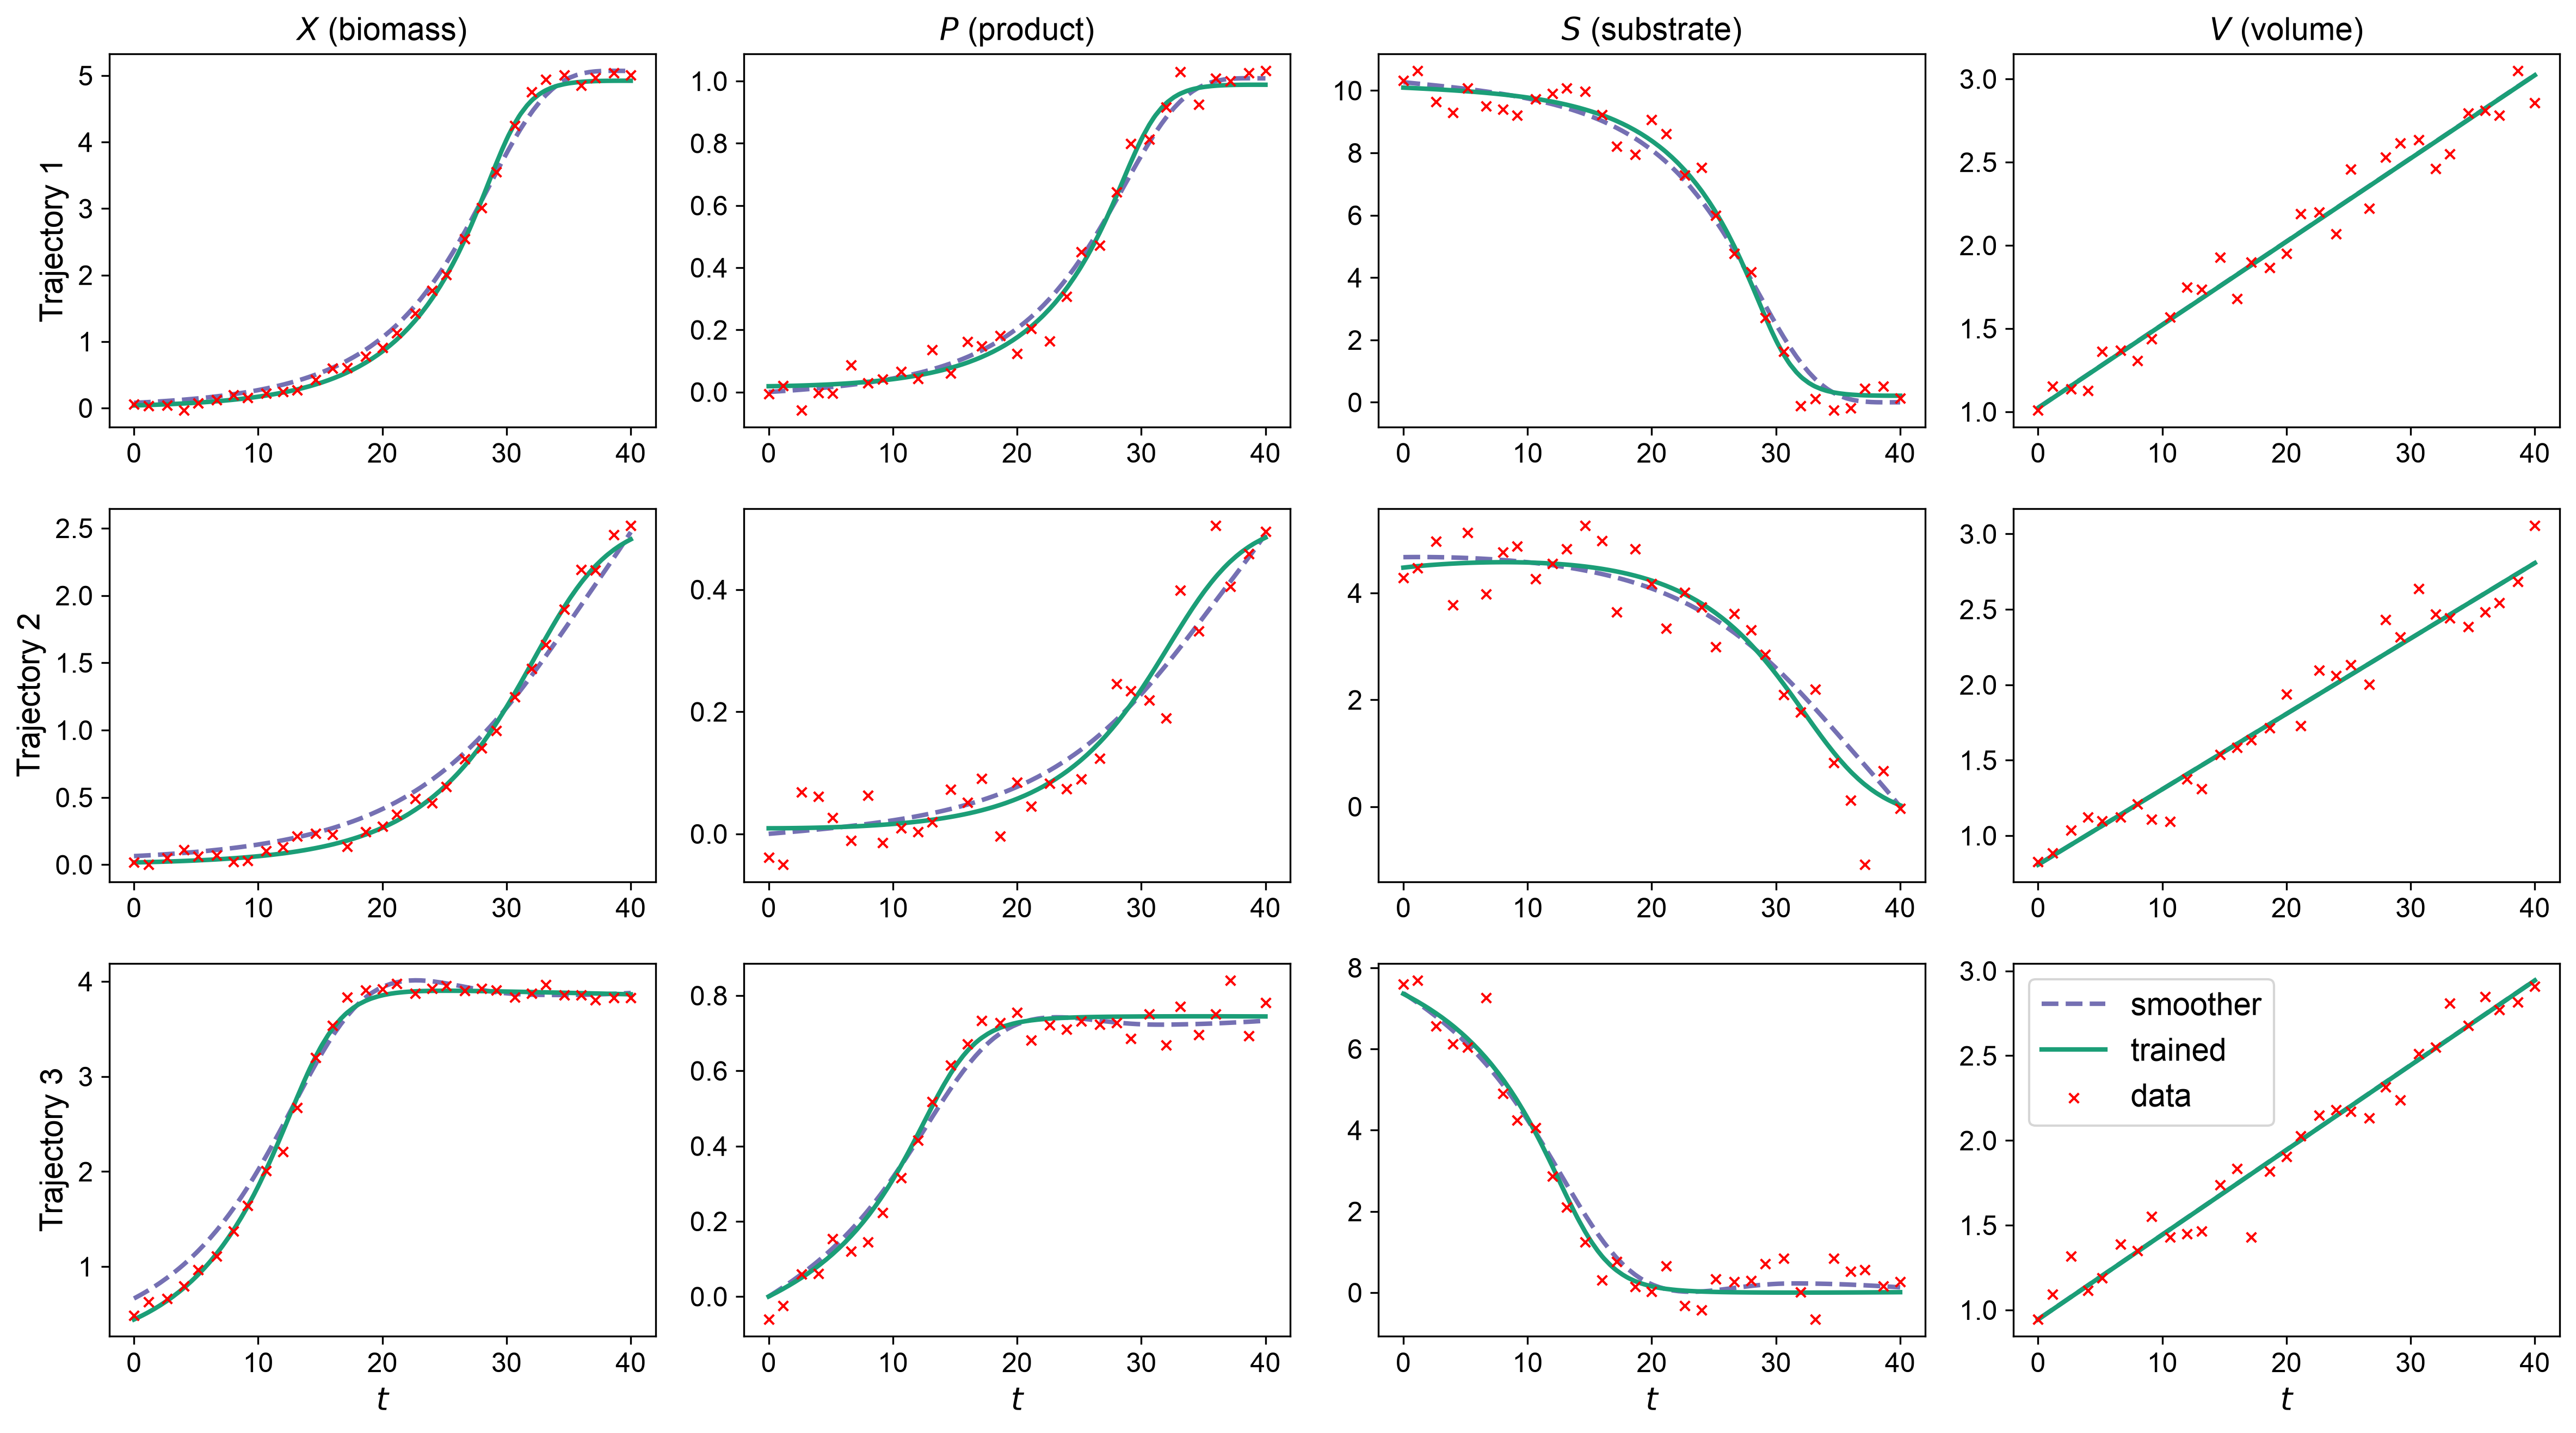

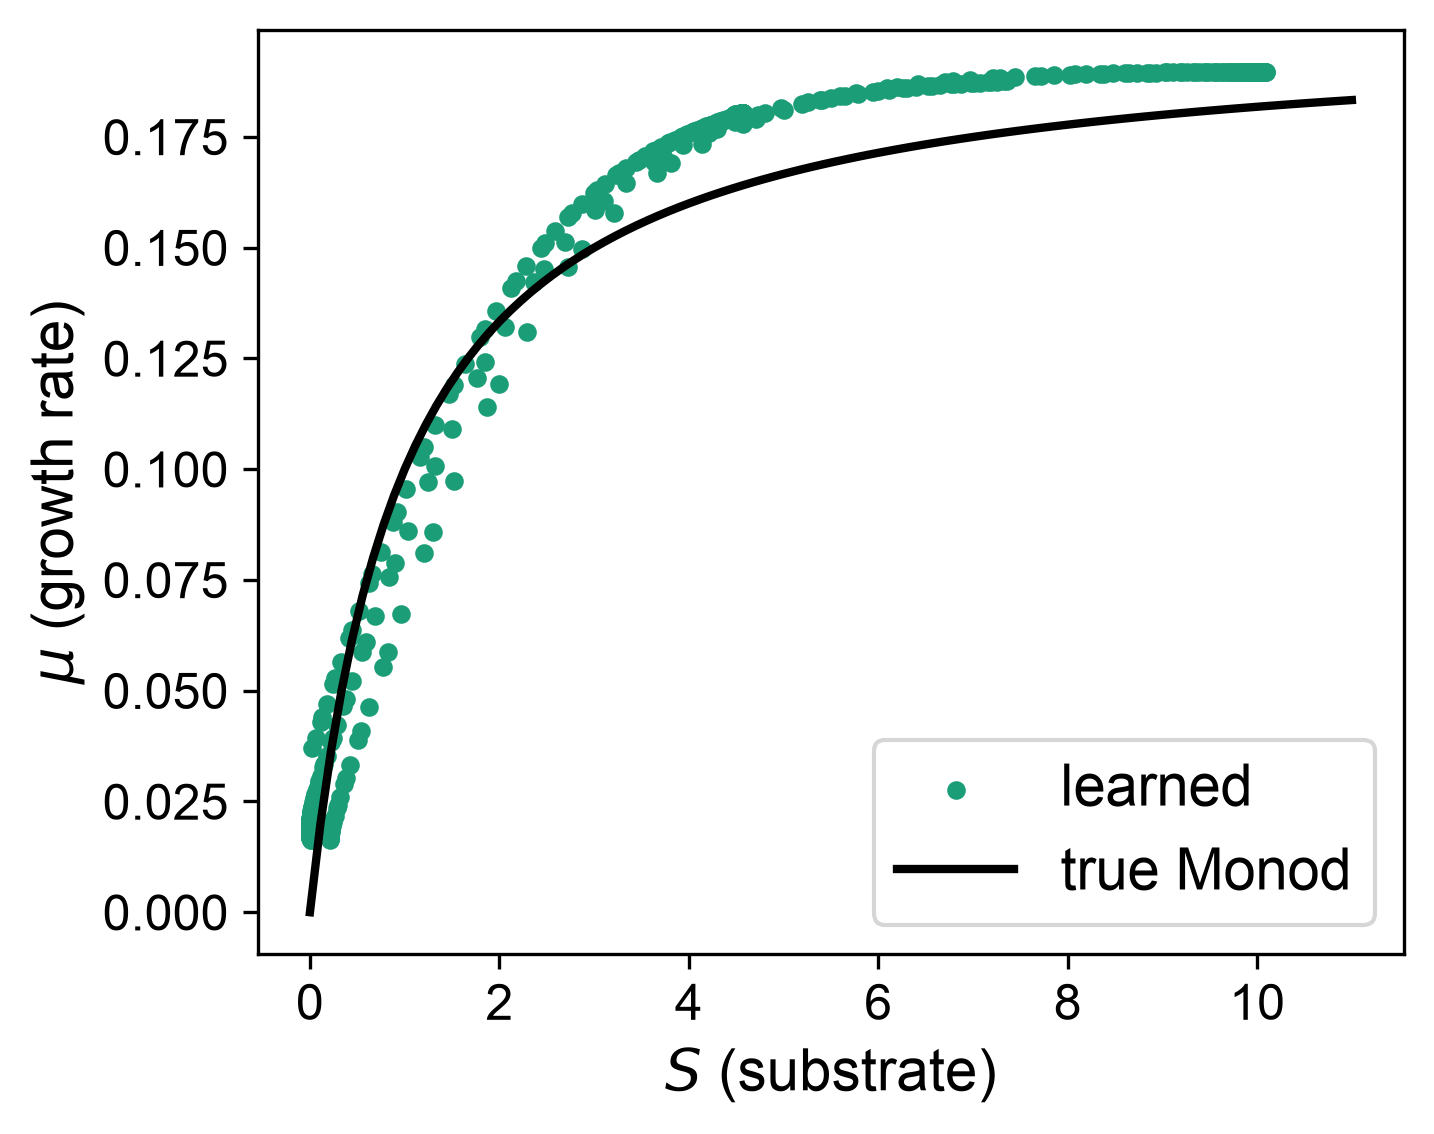

In [17]:
print(f"solver status: {model.termination}")
smoother_data = model.smoother_data
trained_data = model.trained_data

datasets = [
    (smoother_data, "smoother", {"color": "C2", "ls": "--"}),
    (trained_data, "trained", {"color": "C0", "ls": "-"}),
]
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES,
    nn_output_names=OUTPUT_NAME,
    obs_times=problem.obs_times,
    obs_values=problem.obs_values,
    obs_names=STATE_NAMES,
    groups=["inputs"],
    legend_placement="last",
)
plt.show()

fig_mu, ax = plt.subplots(figsize=(5, 4))
for b_ in range(problem.num_trajectories):
    ax.scatter(
        trained_data[b_].nn_input[:, 2],
        trained_data[b_].nn_output[:, 0],
        s=12,
        color="C0",
        label="learned" if b_ == 0 else None,
    )
S_grid = np.linspace(0, 11, 100)
ax.plot(
    S_grid,
    FB_PARAMS["mu_max"] * S_grid / (FB_PARAMS["Ks"] + S_grid),
    "k-",
    label="true Monod",
)
ax.set_xlabel("$S$ (substrate)")
ax.set_ylabel(r"$\mu$ (growth rate)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: a new batch, predicted by both

A batch neither model has seen: 0.2 g/L of cells, 7 g/L of substrate and 0.9 L, run for 60 h,
20 h past the training batches. `predict` builds the same problem, holds the network fixed and
solves the DAE with the states non-negative; `slack_coef` is the price on moving $\mu$ away
from the network's value where a constraint would otherwise break.

In [18]:
new_problem = FedBatchBioreactorProblem(
    params=FB_PARAMS,
    ics=np.array([[0.20, 0.0, 7.0, 0.90]]),
    input_dim=INPUT_DIM,
    z_dim=Z_DIM,
    t_span=(0.0, 60.0),
    nfe=45,
    ncp=3,
    obs_dim=OBS_DIM,
)
prediction = model.predict(
    new_problem,
    slack_coef=1e-5,
)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===


=== Solving inference model ===


  Inference: ok / optimal


In [19]:
states = prediction[0].nn_input
print(f"lowest state value: {states.min():.3f} (>= 0)")

lowest state value: 0.000 (>= 0)


Now the true model and the neural ODE on the same batch.

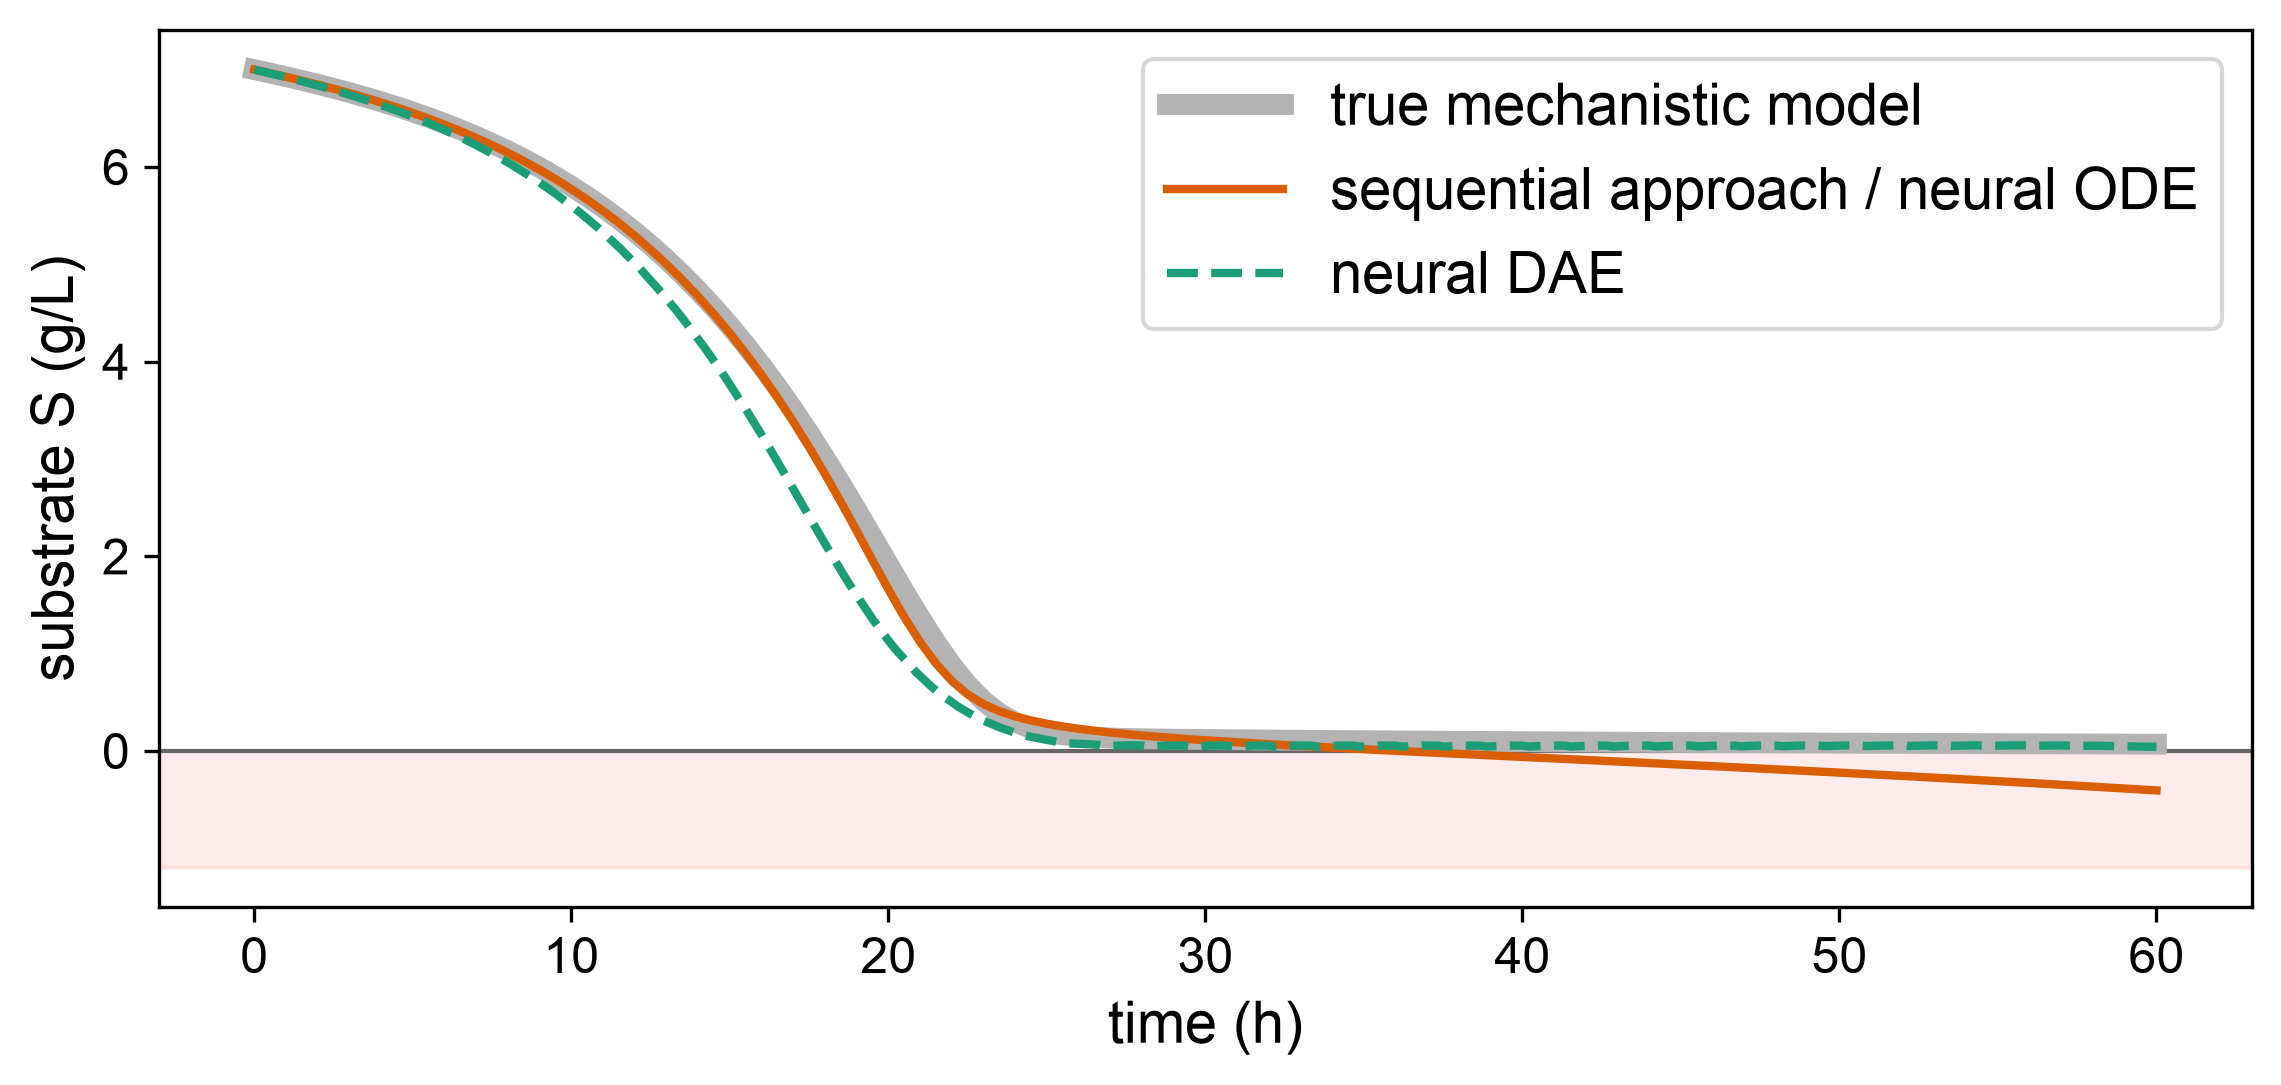

                            true model  neural ODE  neural DAE
lowest S (g/L)                    0.07       -0.41       0.041
hours with S < 0                     0          24           0
biomass X at 60 h (g/L)           3.51        3.75        3.53


In [20]:
ic_A = np.array([0.20, 0.0, 7.0, 0.90])
tt = np.linspace(0, 60, 121)
truth = solve_ivp(
    true_rhs,
    (0, 60),
    ic_A,
    t_eval=tt,
    args=(ic_A[2],),
    rtol=1e-10,
    atol=1e-12,
)
node = np.asarray(simulate(mu_net, jnp.array(ic_A), jnp.array(tt)))
pred_A = prediction[0]
t_dae = np.asarray(pred_A.sampling_times)
S_dae = pred_A.nn_input[:, 2]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axhspan(
    -1.2,
    0,
    color="red",
    alpha=0.08,
)
ax.axhline(
    0,
    color="0.4",
    lw=1,
)
ax.plot(
    tt,
    truth.y[2],
    color="0.7",
    lw=5,
    label="true mechanistic model",
)
ax.plot(
    tt,
    node[:, 2],
    "C1",
    lw=2,
    label="sequential approach / neural ODE",
)
ax.plot(
    t_dae,
    S_dae,
    "C0--",
    lw=2,
    label="neural DAE",
)
ax.set_xlabel("time (h)")
ax.set_ylabel("substrate S (g/L)")
ax.legend()
plt.show()

S_node = node[:, 2]
print(f"{'':26s}{'true model':>12s}{'neural ODE':>12s}{'neural DAE':>12s}")
print(f"{'lowest S (g/L)':26s}{truth.y[2].min():12.2f}{S_node.min():12.2f}{S_dae.min():12.3f}")
print(f"{'hours with S < 0':26s}{0:12d}{np.mean(S_node < 0) * 60:12.0f}{0:12d}")
print(f"{'biomass X at 60 h (g/L)':26s}{truth.y[0, -1]:12.2f}{node[-1, 0]:12.2f}"
      f"{pred_A.nn_input[-1, 0]:12.2f}")

**What to read in the output**

- The neural ODE fits the three training batches, then drives the substrate below zero on the
  new batch: its network still predicts growth when the substrate has run out, and nothing in
  the model forbids a negative concentration.
- The neural DAE gives a substrate that never goes negative.
- Feasible is not the same as accurate: check the errors against the true model, not only the
  sign.

## Try it

- Integrate the **neural DAE's** network with `solve_ivp` instead of solving it with `predict`.
  Does its substrate go negative too? What does that say about where the constraint does the
  work?
- Keep only the $X$ and $S$ columns as measurements, as in the SiNDAE
  [partial observation example](https://alves-research-group.github.io/SiNDAE/fedbatch-partial-obs-example/).
  What else has to change?
- Raise `slack_coef` to `1e-1`. The slacks become expensive. What happens to the solve?